<a href="https://colab.research.google.com/github/Doumbia07/DI_Bootcamp/blob/main/exercice_XP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Tableau comparatif : Machine Learning traditionnel vs Deep Learning

| Aspect | Machine Learning traditionnel | Deep Learning |
|--------|-------------------------------|---------------|
| Feature Engineering | Manuel, nécessite une expertise du domaine | Automatique, les caractéristiques sont apprises |
| Data Processing | Nécessite des données propres et structurées | Peut traiter des données brutes (images, texte, audio) |
| Scalability | Moins scalable pour de très grands volumes | Très scalable avec le hardware (GPU/TPU) |
| Pattern Discovery | Limité aux relations linéaires ou simples | Découvre des motifs complexes et hiérarchiques |
| Computational Requirements | Modéré, peut tourner sur CPU | Élevé, nécessite souvent des GPU |

**Exemple où la ML traditionnelle est mieux adaptée** :  
La prédiction de prix immobiliers à partir de quelques caractéristiques tabulées (surface, nombre de pièces, localisation) – les relations sont souvent linéaires et les données sont structurées.

**Exemple où le Deep Learning est supérieur** :  
La reconnaissance d’objets dans des images – les réseaux de neurones convolutifs apprennent automatiquement des représentations hiérarchiques des pixels.

**Pourquoi le Deep Learning est avantageux pour les données non structurées** :  
Les données non structurées (images, texte, audio) ne peuvent pas être facilement résumées par des caractéristiques prédéfinies. Le Deep Learning, grâce à ses multiples couches, apprend des représentations de plus en plus abstraites directement à partir des données brutes, sans intervention humaine pour l’ingénierie des caractéristiques. Cela lui permet de capturer des motifs complexes et d’atteindre des performances élevées là où les méthodes traditionnelles échouent.

Exercice 2 : schéma ANN (et description)

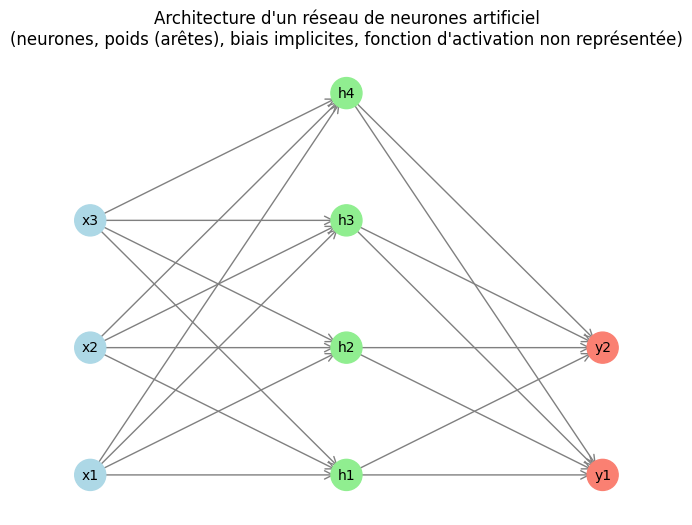

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_ann():
    G = nx.DiGraph()
    layers = {
        'input': [(-2, i) for i in range(3)],
        'hidden': [(0, i) for i in range(4)],
        'output': [(2, i) for i in range(2)]
    }
    for layer_name, positions in layers.items():
        for pos in positions:
            G.add_node(pos, layer=layer_name)
    for pos_in in layers['input']:
        for pos_hid in layers['hidden']:
            G.add_edge(pos_in, pos_hid)
    for pos_hid in layers['hidden']:
        for pos_out in layers['output']:
            G.add_edge(pos_hid, pos_out)

    pos = {node: node for node in G.nodes()}
    layer_colors = {'input': 'lightblue', 'hidden': 'lightgreen', 'output': 'salmon'}
    node_colors = [layer_colors[G.nodes[node]['layer']] for node in G.nodes()]

    plt.figure(figsize=(8, 6))
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=500)
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle='->', arrowsize=15, edge_color='gray')
    labels = {
        (-2,0): 'x1', (-2,1): 'x2', (-2,2): 'x3',
        (0,0): 'h1', (0,1): 'h2', (0,2): 'h3', (0,3): 'h4',
        (2,0): 'y1', (2,1): 'y2'
    }
    nx.draw_networkx_labels(G, pos, labels, font_size=10)
    plt.title("Architecture d'un réseau de neurones artificiel\n(neurones, poids (arêtes), biais implicites, fonction d'activation non représentée)")
    plt.axis('off')
    plt.show()

# Affichage du schéma
draw_ann()

L'information entre par la couche d'entrée (3 neurones) où chaque neurone reçoit une caractéristique.
Chaque connexion a un poids ; la valeur est multipliée par ce poids, puis on ajoute un biais.
La somme est passée dans une fonction d'activation (par exemple ReLU) pour produire la sortie de chaque neurone caché.
Ce processus est répété entre la couche cachée (4 neurones) et la couche de sortie (2 neurones).
La couche de sortie peut utiliser softmax pour une classification.

 Exercice 3 : génération et visualisation des données

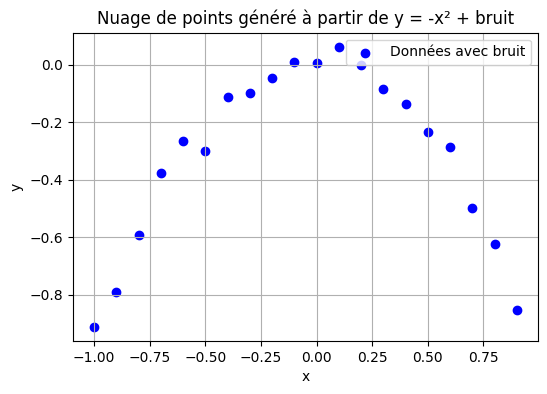

x_train: [-1.00000000e+00 -9.00000000e-01 -8.00000000e-01 -7.00000000e-01
 -6.00000000e-01 -5.00000000e-01 -4.00000000e-01 -3.00000000e-01
 -2.00000000e-01 -1.00000000e-01 -2.22044605e-16  1.00000000e-01]
y_train: [-0.91179738 -0.78999214 -0.5910631  -0.37795534 -0.2666221  -0.29886389
 -0.11249558 -0.09756786 -0.04516094  0.01052993  0.00720218  0.06271368]
x_test: [0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
y_test: [-0.00194811 -0.08391625 -0.13780684 -0.23331628 -0.28529605 -0.50025791
 -0.62434661 -0.85270479]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)          # 20 points
y = -x**2 + np.random.normal(0, 0.05, len(x))

# Nuage de points
plt.figure(figsize=(6, 4))
plt.scatter(x, y, color='blue', label='Données avec bruit')
plt.title("Nuage de points généré à partir de y = -x² + bruit")
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

# Split : 12 premiers pour l'entraînement, 8 derniers pour le test
x_train = x[:12]
y_train = y[:12]
x_test = x[12:]
y_test = y[12:]

print("x_train:", x_train)
print("y_train:", y_train)
print("x_test:", x_test)
print("y_test:", y_test)

Exercice 4 : fonctions d'ajustement polynomial et visualisations

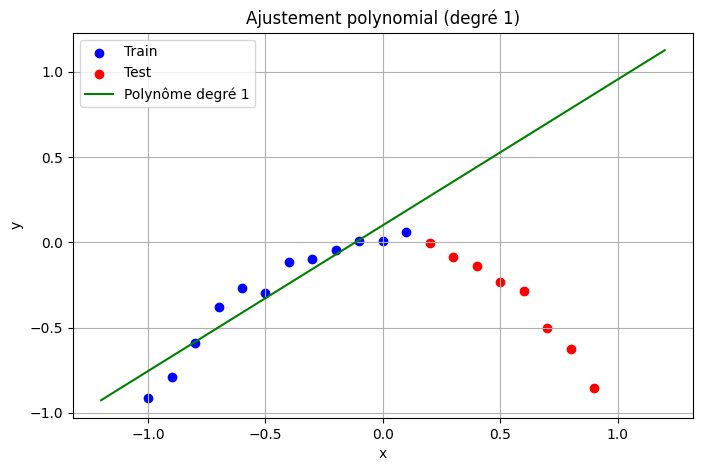

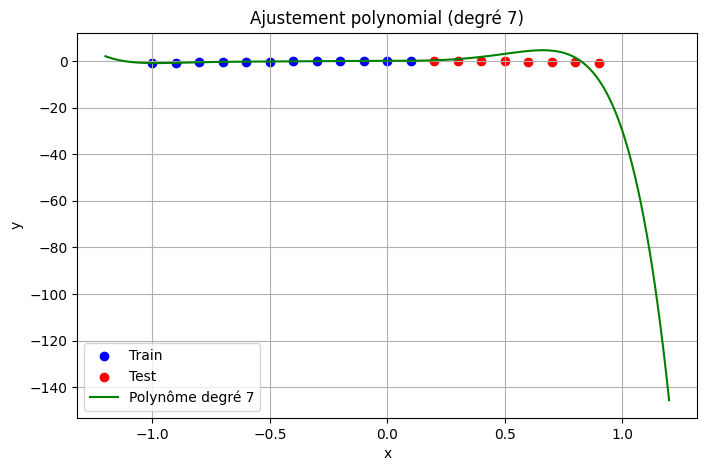

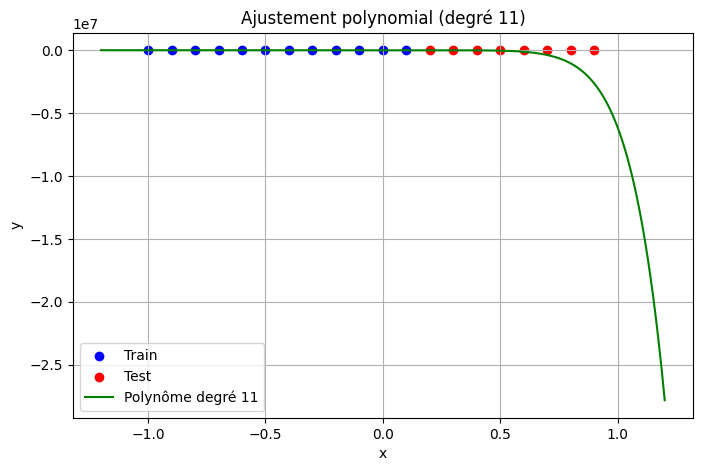

In [5]:
def polynomial_fit(degree):
    """Retourne le polynôme (fonction) ajusté sur les données d'entraînement."""
    coefs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coefs)

def plot_polyfit(degree):
    """Trace les points train/test et la courbe du polynôme de degré donné."""
    p = polynomial_fit(degree)
    x_plot = np.linspace(-1.2, 1.2, 200)
    y_plot = p(x_plot)

    plt.figure(figsize=(8, 5))
    plt.scatter(x_train, y_train, color='blue', label='Train')
    plt.scatter(x_test, y_test, color='red', label='Test')
    plt.plot(x_plot, y_plot, color='green', label=f'Polynôme degré {degree}')
    plt.title(f"Ajustement polynomial (degré {degree})")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

# Visualiser les degrés 1, 7 et 11
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)

Exercice 5 : calcul des RMSE et recherche du degré optimal

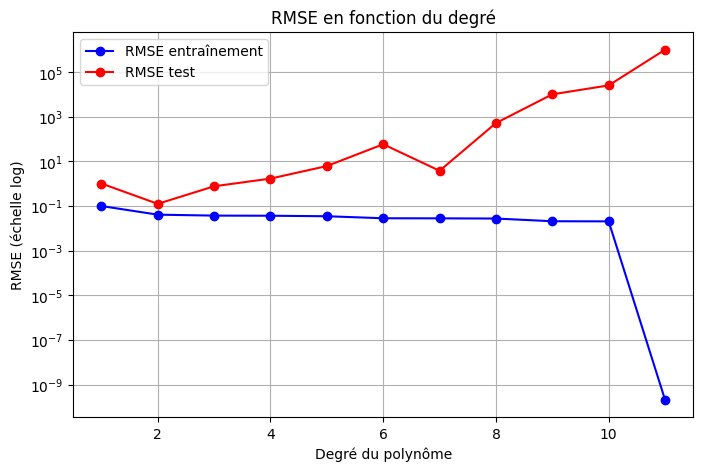

Le degré qui minimise la RMSE sur le test est : 2
Le modèle réel est y = -x² (degré 2). On observe que le degré optimal est bien 2.


In [6]:
degrees = range(1, 12)
rmse_train = []
rmse_test = []

for d in degrees:
    p = polynomial_fit(d)
    y_pred_train = p(x_train)
    y_pred_test = p(x_test)
    rmse_train.append(np.sqrt(mean_squared_error(y_train, y_pred_train)))
    rmse_test.append(np.sqrt(mean_squared_error(y_test, y_pred_test)))

# Tracé en échelle logarithmique
plt.figure(figsize=(8, 5))
plt.plot(degrees, rmse_train, 'bo-', label='RMSE entraînement')
plt.plot(degrees, rmse_test, 'ro-', label='RMSE test')
plt.yscale('log')
plt.xlabel('Degré du polynôme')
plt.ylabel('RMSE (échelle log)')
plt.title('RMSE en fonction du degré')
plt.legend()
plt.grid(True)
plt.show()

# Degré optimal
optimal_degree = degrees[np.argmin(rmse_test)]
print(f"Le degré qui minimise la RMSE sur le test est : {optimal_degree}")
print("Le modèle réel est y = -x² (degré 2)." +
      (" On observe que le degré optimal est bien 2." if optimal_degree == 2 else
       f" Attention, le degré optimal trouvé est {optimal_degree}, pas 2."))